# Pancreas Endocrinogenesis — Visual Method Comparison

Qualitative and quantitative comparison of manifold-learning methods on the Bastidas-Ponce et al.\ (2019) embryonic mouse pancreas scRNA-seq dataset \citep{bastidas2019pancreas}, a standard benchmark for trajectory inference methods used in scvelo \citep{bergen2020scvelo}, CellRank \citep{lange2022cellrank}, and DTNE \citep{wei2025dtne}.

The pancreas dataset captures **multi-branch endocrine differentiation**: Ductal progenitor cells transition through Ngn3-low and Ngn3-high endocrine precursor (EP) states, then through a Pre-endocrine state, before differentiating into four terminal endocrine subtypes ($\alpha$, $\beta$, $\gamma$/Epsilon, $\delta$). This branching topology directly maps onto our synthetic tree benchmarks.

Unlike Paul15, pancreas cell-type labels correspond to relatively discrete developmental stages, making cluster-separation metrics (ARI, NMI) reasonable proxies for trajectory-preservation quality.

## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

# Method classes
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import phate
from entropath import EntroPath
from heatgeo.embedding import HeatGeo
from dtne import DTNE

from utils.bio_utils import (
    get_bio_methods, run_methods, compute_bio_metrics,
    plot_embedding_row, plot_embedding_grid,
    plot_pseudotime_panels, plot_pseudotime_boxplot,
    save_bio_artifacts, save_metrics_csv,
    geodesic_from_root, correlation_triple,
    BIO_PLOT_ORDER,
)

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

## Configuration

Using `K_NN = 15`. EntroPath uses package defaults (`t_power="auto"` for Von Neumann entropy-based selection, `mds_solver="smacof"`, `use_landmarks=None` which auto-enables landmarks when `n > n_landmarks`). For pancreas (n≈3700 with default n_landmarks=2000), landmarks are enabled automatically.

In [2]:
SEED = 42
K_NN = 15

# Pseudotime root — Ductal progenitor cell (matches DTNE notebook)
ROOT_CELL_IDX = 2208

# Output paths
RESULTS_DIR = PROJECT_ROOT / "results" / "pancreas"
FIGURES_DIR = PROJECT_ROOT / "figures" / "pancreas"
DATA_DIR    = PROJECT_ROOT / "data" / "pancreas"
for d in (RESULTS_DIR, FIGURES_DIR, DATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Random seed:  {SEED}")
print(f"k_nn:         {K_NN}")
print(f"Root cell:    {ROOT_CELL_IDX} (Ductal progenitor)")
print(f"Results dir:  {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:  {FIGURES_DIR.relative_to(PROJECT_ROOT)}")

Random seed:  42
k_nn:         15
Root cell:    2208 (Ductal progenitor)
Results dir:  results/pancreas
Figures dir:  figures/pancreas


## Load pancreas dataset

The standard endocrinogenesis dataset comes preprocessed with 30 principal components in `adata.obsm['X_pca']`. We use this directly, matching the convention in the DTNE, PHATE, and scvelo papers.

Tries multiple loading paths in order of preference:
1. Local cache at `data/pancreas/endocrinogenesis.h5ad`
2. scvelo's built-in `pancreas()` loader
3. Manual download (see scvelo docs if neither works)

In [3]:
CACHE_PATH = DATA_DIR / "endocrinogenesis.h5ad"

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Place endocrinogenesis.h5ad in {DATA_DIR}. "
        "Available from the DTNE Google Drive: "
        "https://drive.google.com/drive/folders/1UFKBWFJ7BhzcABpa4DZXssthQuTGMfmU"
    )

adata = sc.read_h5ad(CACHE_PATH)
print(f"Loaded {CACHE_PATH.name}")
print(f"\nShape:     {adata.shape}")
print(f"obs keys:  {list(adata.obs.columns)}")
print(f"obsm keys: {list(adata.obsm.keys())}")

Loaded endocrinogenesis.h5ad

Shape:     (3696, 27998)
obs keys:  ['clusters_coarse', 'clusters', 'S_score', 'G2M_score']
obsm keys: ['X_pca', 'X_umap']


In [4]:
# Use PCA representation (standard convention, 30 components)
if "X_pca" in adata.obsm:
    X = adata.obsm["X_pca"]
    print(f"Using X_pca: shape {X.shape}")
else:
    print("X_pca not in adata.obsm — computing PCA on raw expression")
    sc.pp.pca(adata, n_comps=30)
    X = adata.obsm["X_pca"]
    print(f"Computed X_pca: shape {X.shape}")

# Extract labels and palette
labels       = adata.obs["clusters"].values
label_codes  = adata.obs["clusters"].cat.codes.values

# Get scvelo's default palette if available; otherwise compute one
if "clusters_colors" in adata.uns:
    palette_list = adata.uns["clusters_colors"]
else:
    sc.pl._tools.scatterplots._get_palette(adata, "clusters")
    palette_list = adata.uns["clusters_colors"]

zip_types    = dict(zip(adata.obs["clusters"].cat.categories, palette_list))
cell_colors  = [zip_types[l] for l in labels]
n_clusters   = len(adata.obs["clusters"].cat.categories)

print(f"\nCell types ({n_clusters}):")
for cat in adata.obs["clusters"].cat.categories:
    n = (adata.obs["clusters"] == cat).sum()
    print(f"  {cat:>20s}: {n} cells")

Using X_pca: shape (3696, 50)

Cell types (8):
                Ductal: 916 cells
           Ngn3 low EP: 262 cells
          Ngn3 high EP: 642 cells
         Pre-endocrine: 592 cells
                  Beta: 591 cells
                 Alpha: 481 cells
                 Delta: 70 cells
               Epsilon: 142 cells


## Run all methods

Seven-method bio comparison set from `bio_utils.get_bio_methods`. Single seed; pancreas is small (~3700 cells) so most methods take seconds.

In [5]:
#methods = get_bio_methods(SEED, k_nn=K_NN)

methods = {
    "PCA":       PCA(n_components=2),
    "t-SNE":     TSNE(perplexity=30, random_state=SEED),
    "UMAP":      UMAP(random_state=SEED),
    "PHATE":     phate.PHATE(n_jobs=-2, random_state=SEED, verbose=False),
    "HeatGeo":   HeatGeo(knn=5),
    "DTNE":      DTNE(k_neighbors=15, l1=10),
    "EntroPath": EntroPath(k_neighbors=15, kernel="alpha_decay", mds_solver="smacof",
                           landmarks_method="kmeans", random_state=SEED, verbose=False),
}

print(f"Methods: {list(methods.keys())}\n")

embeddings, runtimes = run_methods(methods, X)

Methods: ['PCA', 't-SNE', 'UMAP', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']

  PCA                done (   0.0s)
  t-SNE              done (   6.2s)
  UMAP               

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


done (  11.0s)
  PHATE              done (   4.3s)
  HeatGeo            Using s_gd2 for MDS. None
done (   9.1s)
  DTNE               done (  10.6s)
  EntroPath          done (   4.6s)  (t_power = 11)

=== Done — 7/7 methods succeeded ===


## Quantitative metrics

ARI/NMI from Agglomerative clustering on each embedding, trustworthiness against the high-dimensional PCA representation, and DTNE-style subsampled DEMaP \citep{wei2025dtne}.

In [6]:
df_pancreas = compute_bio_metrics(
    embeddings, X,
    label_codes=label_codes,
    n_clusters=n_clusters,
    demap_n_subsample=500,
    runtimes=runtimes,
    plot_order=BIO_PLOT_ORDER,
    random_state=SEED,
)

print()
print(df_pancreas.round(3).to_string())
print()
print("=== LaTeX ===")
print(df_pancreas.round(3).to_latex(escape=False, float_format="%.3f"))

Computing bio metrics:
  DEMaP: n_subsample=500, n_repeats=50, knn=50
  Trustworthiness/Continuity: k=15
  X_input == X_ref (single reference, shape (3696, 50))

  PCA                DEMaP = 0.878 ± 0.005, T = 0.907, C = 0.944
  t-SNE              DEMaP = 0.786 ± 0.008, T = 0.988, C = 0.983
  UMAP               DEMaP = 0.936 ± 0.004, T = 0.980, C = 0.984
  PHATE              DEMaP = 0.901 ± 0.005, T = 0.954, C = 0.973
  HeatGeo            DEMaP = 0.869 ± 0.005, T = 0.959, C = 0.975
  DTNE               DEMaP = 0.932 ± 0.004, T = 0.961, C = 0.969
  EntroPath          DEMaP = 0.896 ± 0.004, T = 0.958, C = 0.980

           DEMaP (mean)  DEMaP (std)    ARI    NMI  Trustworthiness  Continuity  Runtime (s)
Method                                                                                      
PCA               0.878        0.005  0.439  0.614            0.907       0.944        0.001
t-SNE             0.786        0.008  0.575  0.702            0.988       0.983        6.169
UMAP      

## Plots

### Embedding row — primary figure

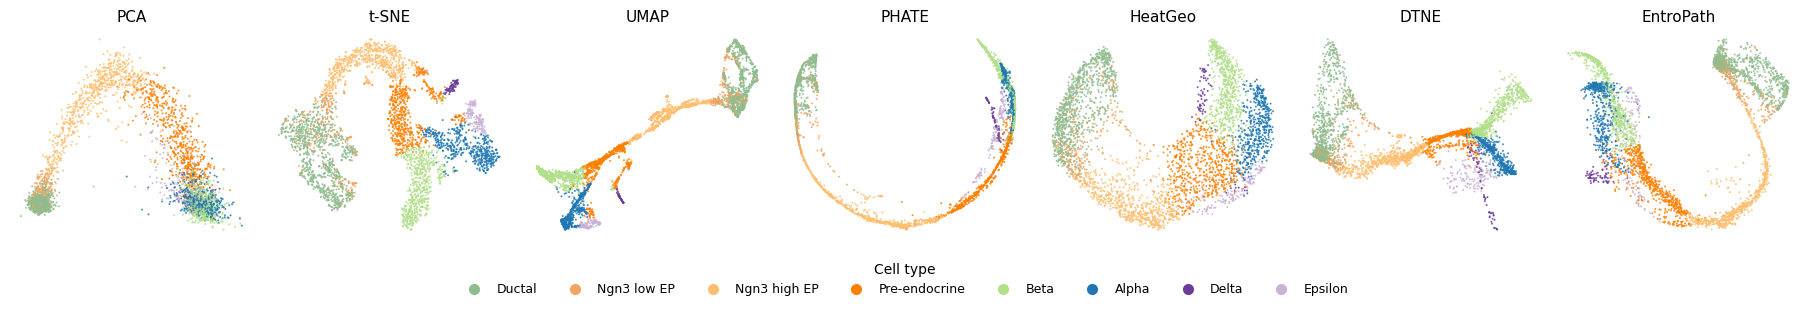

(<Figure size 1820x295 with 7 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>], dtype=object))

In [7]:
plot_embedding_row(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "pancreas_row",
)

### Embedding grid (alternative layout)

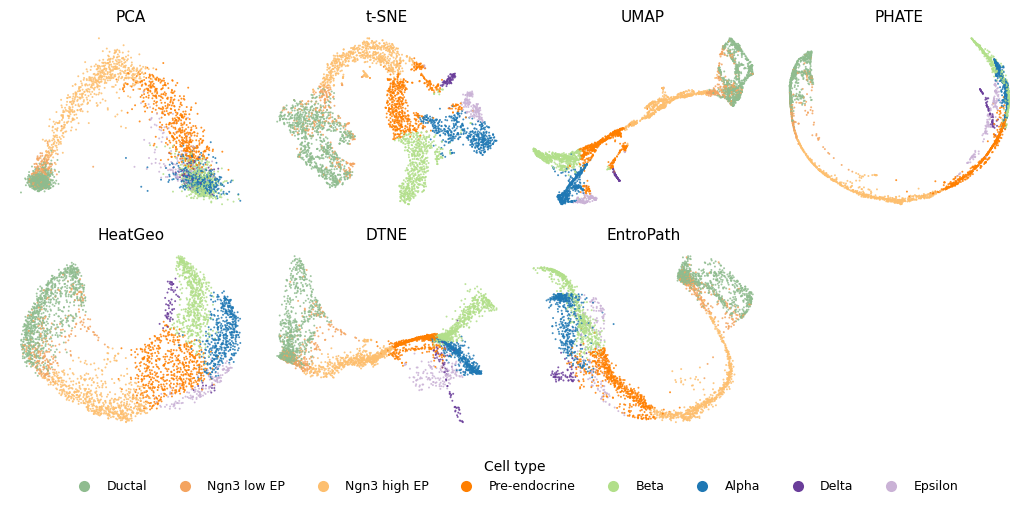

(<Figure size 1040x490 with 8 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>, <Axes: >], dtype=object))

In [8]:
plot_embedding_grid(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "pancreas_grid",
)

## Save artifacts

In [9]:
artifact_path = save_bio_artifacts(
    embeddings, runtimes, labels, label_codes, zip_types,
    X_shape=X.shape,
    config={
        "seed":      SEED,
        "k_nn":      K_NN,
        "root_cell": ROOT_CELL_IDX,
    },
    results_dir=RESULTS_DIR,
    basename="pancreas",
)
metrics_path = save_metrics_csv(df_pancreas, RESULTS_DIR, "pancreas")

print(f"Embeddings saved to {artifact_path.relative_to(PROJECT_ROOT)}")
print(f"Metrics saved to    {metrics_path.relative_to(PROJECT_ROOT)}")

Embeddings saved to results/pancreas/pancreas_embeddings.pkl
Metrics saved to    results/pancreas/pancreas_metrics.csv


## EntroPath downstream analysis (optional)

Pseudotime ordering and pseudotime-based clustering are integrated EntroPath features, not used in the comparison table above (which uses the same Agglomerative clustering for all methods to ensure fairness).

Root cell is index 2208, identified as a Ductal progenitor in the DTNE notebook \citep{wei2025dtne}.

Root cell 2208: type = Ductal


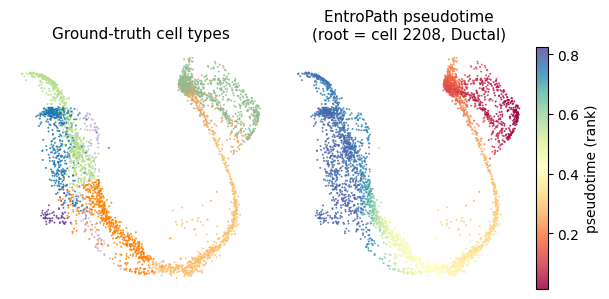


Pseudotime range: [0.013, 0.825]


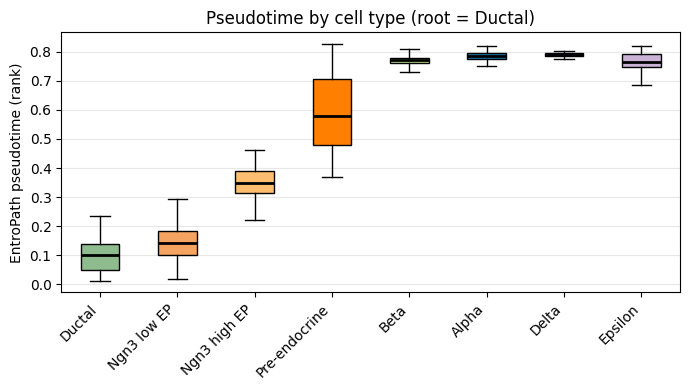

In [10]:
RUN_ENTROPATH_DOWNSTREAM = True

if RUN_ENTROPATH_DOWNSTREAM and "EntroPath" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["EntroPath"], "EntroPath",
        embeddings["EntroPath"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        save_path=FIGURES_DIR / "pancreas_entropath_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_entropath"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["clusters"].cat.categories,
            zip_types,
            method_name="EntroPath",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "pancreas_pseudotime_by_type",
        )
elif RUN_ENTROPATH_DOWNSTREAM:
    print("EntroPath embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_ENTROPATH_DOWNSTREAM = True)")

Root cell 2208: type = Ductal


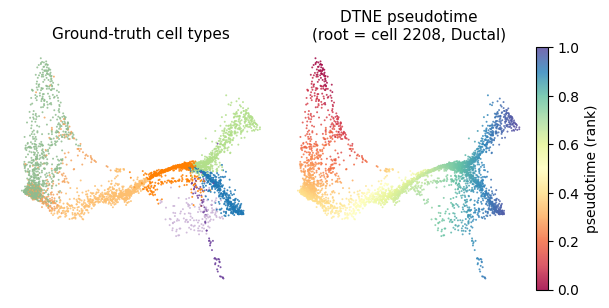


Pseudotime range: [0.000, 1.000]


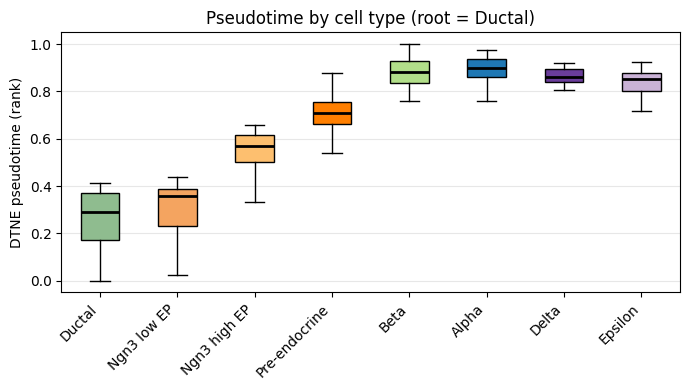

In [11]:
RUN_DTNE_DOWNSTREAM = True

if RUN_DTNE_DOWNSTREAM and "DTNE" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["DTNE"], "DTNE",
        embeddings["DTNE"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        order_method="order_cells",
        save_path=FIGURES_DIR / "pancreas_dtne_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_dtne"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["clusters"].cat.categories,
            zip_types,
            method_name="DTNE",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "dtne_pancreas_pseudotime_by_type",
        )
elif RUN_DTNE_DOWNSTREAM:
    print("DTNE embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_DTNE_DOWNSTREAM = True)")

In [12]:
from scipy.stats import spearmanr

if "pseudotime_entropath" in adata.obs and "pseudotime_dtne" in adata.obs:
    pt_ep = adata.obs["pseudotime_entropath"].values
    pt_dt = adata.obs["pseudotime_dtne"].values
    mask = ~(np.isnan(pt_ep) | np.isnan(pt_dt))
    rho_sp, _ = spearmanr(pt_ep[mask], pt_dt[mask])
    print(f"\nPseudotime Spearman (EntroPath vs DTNE): {rho_sp:.3f}")


Pseudotime Spearman (EntroPath vs DTNE): 0.945


In [13]:
ROOT = ROOT_CELL_IDX
geo = geodesic_from_root(X, ROOT, k_neighbors=20)

reachable = np.isfinite(geo)
n_unreachable = int((~reachable).sum())
if n_unreachable:
    print(f"WARNING: {n_unreachable}/{len(geo)} cells unreachable from root at k=20 "
          f"(graph fragmented); correlations computed on reachable cells only.\n")

pseudotimes = {}
for name, key in [("EntroPath", "pseudotime_entropath"), ("DTNE", "pseudotime_dtne")]:
    if key in adata.obs:
        pseudotimes[name] = adata.obs[key].values
    else:
        print(f"[skip] {key} not in adata.obs")

print(f"Geodesic-pseudotime correlation "
      f"(high-D X_input, k_neighbors=20, root cell {ROOT}, label={labels[ROOT]}):")
print(f"{'Method':<12s}  {'Pearson':>8s}  {'Spearman':>8s}  {'Kendall':>8s}")
print("-" * 44)
rows = []
for name, pt in pseudotimes.items():
    p, s, k = correlation_triple(geo, pt)
    print(f"{name:<12s}  {p:>8.3f}  {s:>8.3f}  {k:>8.3f}")
    rows.append({"Method": name, "Pearson": p, "Spearman": s, "Kendall": k})

df_geo = pd.DataFrame(rows).set_index("Method")
geo_path = RESULTS_DIR / "pancreas_geodesic_pseudotime_corr.csv"
df_geo.to_csv(geo_path)
print(f"\nSaved to {geo_path.relative_to(PROJECT_ROOT)}")
print("\n=== LaTeX ===")
print(df_geo.round(3).to_latex(float_format="%.3f"))

Geodesic-pseudotime correlation (high-D X_input, k_neighbors=20, root cell 2208, label=Ductal):
Method         Pearson  Spearman   Kendall
--------------------------------------------
EntroPath        0.975     0.951     0.832
DTNE             0.991     0.992     0.924

Saved to results/pancreas/pancreas_geodesic_pseudotime_corr.csv

=== LaTeX ===
\begin{tabular}{lrrr}
\toprule
 & Pearson & Spearman & Kendall \\
Method &  &  &  \\
\midrule
EntroPath & 0.975 & 0.951 & 0.832 \\
DTNE & 0.991 & 0.992 & 0.924 \\
\bottomrule
\end{tabular}



In [14]:
n_disconnected = np.sum(~np.isfinite(geo))
if n_disconnected > 0:
    print(f"WARNING: {n_disconnected} cells unreachable from root. "
          f"Increase k_neighbors.")